# 超參數調校(Hyperparameter tuning)

In [1]:
import os
import sys

# 設定 Google Drive 中的套件路徑
nb_path = '/content/drive/Pytorch_Book/colab_env'

# 如果資料夾不存在則自動建立
if not os.path.exists(nb_path):
    os.makedirs(nb_path)

# 將此路徑加到 sys.path 的最前面
if nb_path not in sys.path:
    sys.path.insert(0, nb_path)

## 安裝套件

In [2]:
!pip install ray

## 載入套件

In [ ]:
import os, sys
from pathlib import Path
import tempfile
from typing import cast, Sized

import matplotlib.pyplot as plt
import torch
from torch import nn, optim
from torch.nn import functional as F
from ray import tune
from ray.tune import Checkpoint
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

## 判斷是否有GPU

In [4]:
device = "cuda" if torch.cuda.is_available() else "mps" if torch.mps.is_available() else "cpu"
device

'cuda'

## 建立模型結構

In [5]:
class ConvNet(nn.Module):
    def __init__(self) -> None:
        super(ConvNet, self).__init__()
        # In this example, we don't change the model architecture
        # due to simplicity.
        self.conv1 = nn.Conv2d(1, 3, kernel_size=3)
        self.fc = nn.Linear(192, 10)

    def forward(self, x: torch.Tensor):
        x = F.relu(F.max_pool2d(self.conv1(x), 3))
        x = x.view(-1, 192)
        x = self.fc(x)
        return F.log_softmax(x, dim=1)

## 定義模型訓練及測試函數

In [6]:
# 訓練週期
EPOCH_SIZE = 5


# 定義模型訓練函數
def train(model: nn.Module, optimizer: optim.Optimizer, train_loader: DataLoader) -> None:
    model.train()
    data: torch.Tensor
    target: torch.Tensor
    for data, target in train_loader:
        data, target = data.to(device), target.to(device)
        optimizer.zero_grad()
        output: torch.Tensor = model(data)
        loss = F.nll_loss(output, target)
        loss.backward()
        optimizer.step()


# 定義模型測試函數
def test(model: nn.Module, data_loader: DataLoader) -> float:
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        data: torch.Tensor
        target: torch.Tensor
        for data, target in data_loader:
            data, target = data.to(device), target.to(device)
            outputs: torch.Tensor = model(data)
            # 準確數計算
            _, predicted = torch.max(outputs.data, 1)
            total += target.size(0)
            correct += (predicted == target).sum().item()

    return correct / total

## 定義特徵縮放函數

In [7]:
mnist_transforms = transforms.Compose(
    [
        transforms.ToTensor(),
        transforms.Normalize((0.1307,), (0.3081,)),
    ]
)

## 定義資料載入及模型訓練函數

In [ ]:
# Ray Tune 會將每個試驗的工作目錄切換到暫存目錄，故資料路徑須使用絕對路徑
# 判斷是否為 Colab 環境
is_colab = 'google.colab' in sys.modules
base_path = Path('/content/drive/MyDrive/colab_env') if is_colab else Path('.')
PATH_DATASETS = base_path / "data"  # 預設路徑

In [ ]:
def train_mnist(config):
    # 載入 MNIST 手寫阿拉伯數字資料
    train_loader = DataLoader(
        datasets.MNIST(PATH_DATASETS, train=True, download=True, transform=mnist_transforms), batch_size=64, shuffle=True
    )
    test_loader = DataLoader(
        datasets.MNIST(PATH_DATASETS, train=False, download=True, transform=mnist_transforms), batch_size=64, shuffle=True
    )

    # 建立模型
    model = ConvNet().to(device)

    # 優化器，使用組態參數
    optimizer = optim.SGD(model.parameters(), lr=config["lr"], momentum=config["momentum"])
    # 訓練 10 週期
    for i in range(10):
        train(model, optimizer, train_loader)
        # 測試
        acc = test(model, test_loader)

        # 每 5 週期存檔一次，並以 Checkpoint 物件回傳，Ray Tune 才會將檔案同步保存到永久儲存位置
        if i % 5 == 0:
            with tempfile.TemporaryDirectory() as tmpdir:
                torch.save(model.state_dict(), os.path.join(tmpdir, "model.pth"))
                # 訓練結果交回給 Ray Tune
                tune.report({"mean_accuracy": acc}, checkpoint=Checkpoint.from_directory(tmpdir))
        else:
            # 訓練結果交回給 Ray Tune
            tune.report({"mean_accuracy": acc})

## 參數調校

In [10]:
# 參數組合
search_space = {
    # "lr": tune.sample_from(lambda spec: 10**(-10 * np.random.rand())),
    "lr": tune.grid_search([0.01, 0.1, 0.5]),  # 每一選項都要測試
    "momentum": tune.uniform(0.1, 0.9),  # 均勻分配抽樣
}

# 加下一行，採分散式處理
# ray.init(address="auto")

# 執行參數調校
# analysis = tune.run(train_mnist, config=search_space, resources_per_trial={'gpu': 1})
analysis = tune.run(train_mnist, config=search_space)

2026-08-09 04:07:08,389	INFO worker.py:2024 -- Started a local Ray instance.
2026-08-09 04:07:11,242	INFO tune.py:253 -- Initializing Ray automatically. For cluster usage or custom Ray initialization, call `ray.init(...)` before `tune.run(...)`.
2026-08-09 04:07:11,262	INFO tensorboardx.py:43 -- pip install "ray[tune]" to see TensorBoard files.
2026-08-09 04:07:11,263	WARNING callback.py:132 -- The TensorboardX logger cannot be instantiated because either TensorboardX or one of it's dependencies is not installed. Please make sure you have the latest version of TensorboardX installed: `pip install -U tensorboardx`


+--------------------------------------------------------------------+
| Configuration for experiment     train_mnist_2026-08-09_04-07-11   |
+--------------------------------------------------------------------+
| Search algorithm                 BasicVariantGenerator             |
| Scheduler                        FIFOScheduler                     |
| Number of trials                 3                                 |
+--------------------------------------------------------------------+

View detailed results here: /root/ray_results/train_mnist_2026-08-09_04-07-11

Trial status: 3 PENDING
Current time: 2026-08-09 04:07:11. Total running time: 0s
Logical resource usage: 2.0/2 CPUs, 0/1 GPUs (0.0/1.0 accelerator_type:T4)
+--------------------------------------------------------+
| Trial name                status       momentum     lr |
+--------------------------------------------------------+
| train_mnist_cbc3b_00000   PENDING      0.789442   0.01 |
| train_mnist_cbc3b_00001   PE

  0%|          | 0.00/9.91M [00:00<?, ?B/s]
  1%|          | 65.5k/9.91M [00:00<00:18, 532kB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 459kB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 469kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.46MB/s]



Trial status: 2 RUNNING | 1 PENDING
Current time: 2026-08-09 04:07:41. Total running time: 30s
Logical resource usage: 2.0/2 CPUs, 0/1 GPUs (0.0/1.0 accelerator_type:T4)
+--------------------------------------------------------+
| Trial name                status       momentum     lr |
+--------------------------------------------------------+
| train_mnist_cbc3b_00000   RUNNING      0.789442   0.01 |
| train_mnist_cbc3b_00001   RUNNING      0.400715   0.1  |
| train_mnist_cbc3b_00002   PENDING      0.113112   0.5  |
+--------------------------------------------------------+

Trial train_mnist_cbc3b_00001 finished iteration 1 at 2026-08-09 04:08:01. Total running time: 49s
+------------------------------------------------------------+
| Trial train_mnist_cbc3b_00001 result                       |
+------------------------------------------------------------+
| checkpoint_dir_name                      checkpoint_000000 |
| time_this_iter_s                                  36.23555 |
|

(train_mnist pid=3877) Checkpoint successfully created at: Checkpoint(filesystem=local, path=/root/ray_results/train_mnist_2026-08-09_04-07-11/train_mnist_cbc3b_00000_0_lr=0.0100,momentum=0.7894_2026-08-09_04-07-11/checkpoint_000000)
100%|██████████| 4.54k/4.54k [00:00<00:00, 16.5MB/s] [repeated 7x across cluster] (Ray deduplicates logs by default. Set RAY_DEDUP_LOGS=0 to disable log deduplication, or see https://docs.ray.io/en/master/ray-observability/user-guides/configure-logging.html#log-deduplication for more options.)
 22%|██▏       | 360k/1.65M [00:00<00:00, 1.63MB/s] [repeated 13x across cluster]


...


Trial status: 2 TERMINATED | 1 RUNNING
Current time: 2026-08-09 04:13:12. Total running time: 6min 0s
Logical resource usage: 1.0/2 CPUs, 0/1 GPUs (0.0/1.0 accelerator_type:T4)
+-----------------------------------------------------------------------------------------------+
| Trial name                status         momentum     lr      acc     iter     total time (s) |
+-----------------------------------------------------------------------------------------------+
| train_mnist_cbc3b_00002   RUNNING        0.113112   0.5    0.8357        1            17.4619 |
| train_mnist_cbc3b_00000   TERMINATED     0.789442   0.01   0.9688       10           301.58   |
| train_mnist_cbc3b_00001   TERMINATED     0.400715   0.1    0.9651       10           302.105  |
+-----------------------------------------------------------------------------------------------+

Trial train_mnist_cbc3b_00002 finished iteration 2 at 2026-08-09 04:13:12. Total running time: 6min 0s
+-------------------------------

(train_mnist pid=5280) Checkpoint successfully created at: Checkpoint(filesystem=local, path=/root/ray_results/train_mnist_2026-08-09_04-07-11/train_mnist_cbc3b_00002_2_lr=0.5000,momentum=0.1131_2026-08-09_04-07-11/checkpoint_000001)



Trial train_mnist_cbc3b_00002 finished iteration 7 at 2026-08-09 04:14:35. Total running time: 7min 24s
+--------------------------------------------------+
| Trial train_mnist_cbc3b_00002 result             |
+--------------------------------------------------+
| checkpoint_dir_name                              |
| time_this_iter_s                         16.5259 |
| time_total_s                             118.496 |
| training_iteration                             7 |
| mean_accuracy                             0.1135 |
+--------------------------------------------------+

Trial status: 2 TERMINATED | 1 RUNNING
Current time: 2026-08-09 04:14:42. Total running time: 7min 31s
Logical resource usage: 1.0/2 CPUs, 0/1 GPUs (0.0/1.0 accelerator_type:T4)
+-----------------------------------------------------------------------------------------------+
| Trial name                status         momentum     lr      acc     iter     total time (s) |
+------------------------------------------

2026-08-09 04:15:25,008	INFO tune.py:1007 -- Wrote the latest version of all result files and experiment state to '/root/ray_results/train_mnist_2026-08-09_04-07-11' in 0.0087s.



Trial train_mnist_cbc3b_00002 finished iteration 10 at 2026-08-09 04:15:24. Total running time: 8min 13s
+--------------------------------------------------+
| Trial train_mnist_cbc3b_00002 result             |
+--------------------------------------------------+
| checkpoint_dir_name                              |
| time_this_iter_s                         16.7029 |
| time_total_s                             167.872 |
| training_iteration                            10 |
| mean_accuracy                             0.1028 |
+--------------------------------------------------+

Trial train_mnist_cbc3b_00002 completed after 10 iterations at 2026-08-09 04:15:24. Total running time: 8min 13s

Trial status: 3 TERMINATED
Current time: 2026-08-09 04:15:25. Total running time: 8min 13s
Logical resource usage: 1.0/2 CPUs, 0/1 GPUs (0.0/1.0 accelerator_type:T4)
+-----------------------------------------------------------------------------------------------+
| Trial name                status    

## 取得實驗的參數

In [11]:
for i in analysis.get_all_configs().keys():
    print(analysis.get_all_configs()[i])

{'lr': 0.01, 'momentum': 0.7894420085506318}
{'lr': 0.1, 'momentum': 0.400714953125865}
{'lr': 0.5, 'momentum': 0.11311239849025566}


## 對訓練過程的準確率繪圖

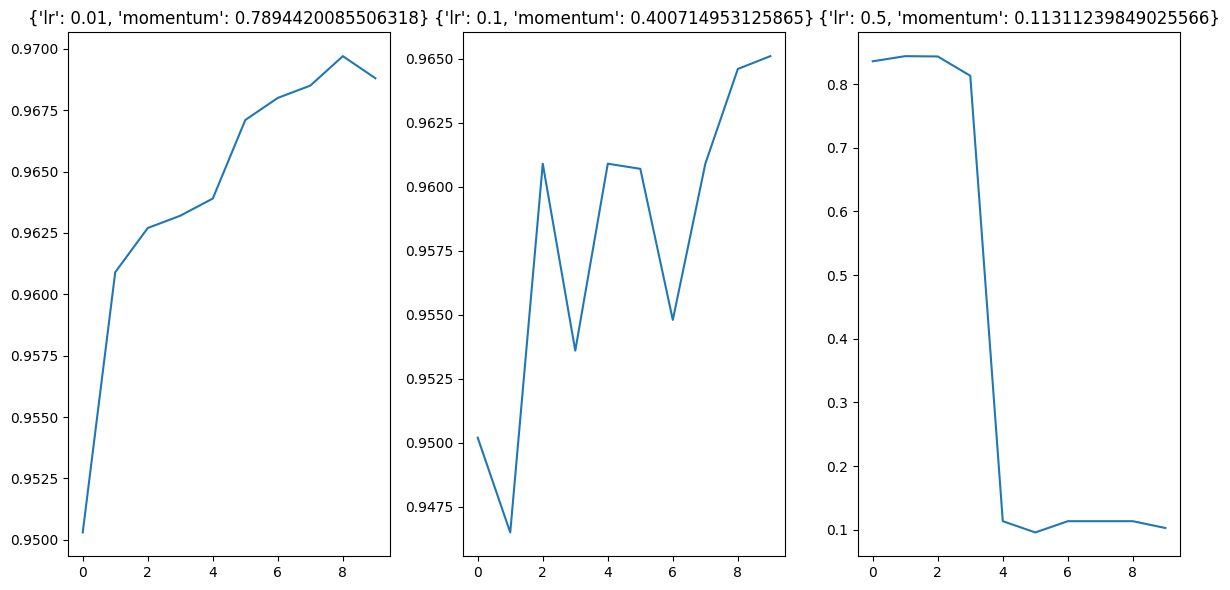

In [12]:
# 取得實驗的參數
config_list = []
for i in analysis.get_all_configs().keys():
    config_list.append(analysis.get_all_configs()[i])

# 繪圖
plt.figure(figsize=(12, 6))
dfs = analysis.trial_dataframes
for i, d in enumerate(dfs.values()):
    plt.subplot(1, 3, i + 1)
    plt.title(config_list[i])
    d.mean_accuracy.plot()
plt.tight_layout()
plt.show()

## 顯示詳細調校內容

In [13]:
for i in dfs.keys():
    parameters = i.split("\\")[-1]
    print(f'{parameters}\n', dfs[i][['mean_accuracy', 'time_total_s']])

cbc3b_00000
    mean_accuracy  time_total_s
0         0.9503     36.257469
1         0.9609     66.043603
2         0.9627     95.880359
3         0.9632    125.320524
4         0.9639    154.645601
5         0.9671    184.077543
6         0.9680    213.372178
7         0.9685    242.961311
8         0.9697    272.419705
9         0.9688    301.579656
cbc3b_00001
    mean_accuracy  time_total_s
0         0.9502     36.235551
1         0.9465     66.030431
2         0.9609     95.917065
3         0.9536    125.499237
4         0.9609    154.910612
5         0.9607    184.459483
6         0.9548    213.959327
7         0.9609    243.451925
8         0.9646    272.932936
9         0.9651    302.104769
cbc3b_00002
    mean_accuracy  time_total_s
0         0.8357     17.461876
1         0.8438     35.178741
2         0.8433     51.475810
3         0.8130     68.012255
4         0.1135     84.625247
5         0.0958    101.970328
6         0.1135    118.496271
7         0.1135    134.893448


In [14]:
analysis.results_df

,mean_accuracy,timestamp,checkpoint_dir_name,done,training_iteration,date,time_this_iter_s,time_total_s,pid,hostname,node_ip,time_since_restore,iterations_since_restore,experiment_tag,config/lr,config/momentum
trial_id,,,,,,,,,,,,,,,,
cbc3b_00000,0.9688,1786248746,None,True,10,2026-08-09_04-12-26,29.159950,301.579656,3877,fbcdcbd4d96e,172.28.0.12,301.579656,10,"0_lr=0.0100,momentum=0.7894",0.01,0.789442
cbc3b_00001,0.9651,1786248747,None,True,10,2026-08-09_04-12-27,29.171833,302.104769,3878,fbcdcbd4d96e,172.28.0.12,302.104769,10,"1_lr=0.1000,momentum=0.4007",0.10,0.400715
cbc3b_00002,0.1028,1786248924,None,True,10,2026-08-09_04-15-24,16.702930,167.871665,5280,fbcdcbd4d96e,172.28.0.12,167.871665,10,"2_lr=0.5000,momentum=0.1131",0.50,0.113112


## 取得最佳模型參數

In [15]:
best_trial = analysis.get_best_trial("mean_accuracy", "max", "last")
assert best_trial is not None
best_trial.config

{'lr': 0.01, 'momentum': 0.7894420085506318}

## 載入最佳模型

In [16]:
assert best_trial is not None
best_checkpoint = analysis.get_best_checkpoint(best_trial, "mean_accuracy", "max")
assert best_checkpoint is not None

with best_checkpoint.as_directory() as checkpoint_dir:
    state_dict = torch.load(os.path.join(checkpoint_dir, "model.pth"))

model = ConvNet().to(device)
model.load_state_dict(state_dict)

<All keys matched successfully>

## 測試資料評分(Score Model)

In [ ]:
test_ds = datasets.MNIST(PATH_DATASETS, train=False, download=True, transform=mnist_transforms)

# 建立 DataLoader
test_loader = DataLoader(test_ds, shuffle=False, batch_size=1_000)

model.eval()
correct = 0
with torch.no_grad():
    data: torch.Tensor
    target: torch.Tensor
    for data, target in test_loader:
        data, target = data.to(device), target.to(device)
        output = model(data)

        # 正確筆數
        _, predicted = torch.max(output, 1)
        correct += (predicted == target).sum().item()

# 顯示測試結果
data_count = len(cast(Sized, test_loader.dataset))
percentage = 100.0 * correct / data_count
print(f'準確率: {correct}/{data_count} ({percentage:.0f}%)\n')

準確率: 9671/10000 (97%)

